# Urban Heat & Cooling-Priority Mapping — Week 1 Verification Gates

**NUS-ISS Practice Module.** One notebook, run top to bottom:

1. **Setup** — install deps, authenticate Earth Engine, mount Drive (all auth up front)
2. **G1** — GEE composite pull (Landsat + Sentinel-2)
3. **G3** — end-to-end smoke test (tile → downscale → toy land cover → subzone join → dummy score)
4. **G4** — downscaling sanity check (regression R² on held-out pixels)
5. **G2** — NEA API depth check
6. **G5** — labeling agreement (Cohen's kappa on 20 shared points)
7. **Final** — compiled summary of all five gates

Run cells in order. G3 depends on G1's Cells having run; G4 depends on G3; G2 and G5 are independent and can be run any time after Setup.

---
# SETUP — run once per session

## Setup 1 — Install dependencies

In [1]:
# --- SETUP CELL 1: Install all dependencies used across every gate ---------
!pip install -q geemap rasterio geopandas shapely scikit-learn requests pandas folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 22.5 MB/s eta 0:00:00


## Setup 2 — Authenticate & initialize Earth Engine

In [2]:
# --- SETUP CELL 2: Authenticate & initialize Earth Engine -------------------
import ee

PROJECT_ID = "nus-iss-urban-heat-sg"  # <-- your GCP project (make sure this exact
                                      #     ID is created + Earth Engine-registered at
                                      #     https://console.cloud.google.com/
                                      #     and https://code.earthengine.google.com/register)

if PROJECT_ID == "your-gcp-project-id":
    raise ValueError(
        "PROJECT_ID is still the placeholder. Set it to your actual GCP project ID "
        "(lowercase-with-hyphens, from console.cloud.google.com), then re-run this cell."
    )

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print("EE initialized OK, project:", PROJECT_ID)

EE initialized OK, project: nus-iss-urban-heat-sg


## Setup 3 — Mount Google Drive

In [3]:
# --- SETUP CELL 3: Mount Google Drive (needed for exports/viewing later) ---
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted at /content/drive")

Mounted at /content/drive
Drive mounted at /content/drive


## Setup 4 — Initialize shared gate-results tracker

In [4]:
# --- SETUP CELL 4: Initialize shared results tracker for all gates ---------
# Every gate (G1, G2, G3, G4, G5) writes its verdict into this dict.
# The LAST cell of the notebook compiles everything into one summary.
gate_results = {}
print("gate_results initialized — will be populated as each gate runs.")

gate_results initialized — will be populated as each gate runs.


---
# G1 — GEE data pull + cloud-free composite check for Singapore

## G1.1 — Define AOI (Singapore) and date window

In [5]:
# --- CELL 2: AOI + date window -----------------------------------------------
# NOTE: this assumes SETUP CELL 2 (EE auth) has already run in this session.
# Singapore bounding box, generous buffer to be safe with subzone edges
sg_bbox = ee.Geometry.Rectangle([103.55, 1.15, 104.10, 1.48])

END_DATE = "2026-07-16"       # today
START_DATE = "2024-07-16"     # last 2 years
CLOUD_COVER_MAX = 70          # pre-filter threshold on scene metadata (loose;
                               # real filtering happens via per-pixel masks below)

print(f"AOI: Singapore bbox | Window: {START_DATE} to {END_DATE}")

AOI: Singapore bbox | Window: 2024-07-16 to 2026-07-16


## G1.2 — Landsat 8/9 Collection 2 Level 2: mask, scale, composite

In [6]:
# --- CELL 3: Landsat 8/9 Collection 2 Level 2 (surface temp + reflectance) --
def mask_landsat_c2l2(image):
    """Cloud/shadow/snow mask using QA_PIXEL bits, per USGS C2 L2 spec."""
    qa = image.select("QA_PIXEL")
    # Bits: 1=dilated cloud, 2=cirrus, 3=cloud, 4=cloud shadow, 5=snow
    dilated_cloud = 1 << 1
    cirrus = 1 << 2
    cloud = 1 << 3
    shadow = 1 << 4
    snow = 1 << 5
    mask = (
        qa.bitwiseAnd(dilated_cloud).eq(0)
        .And(qa.bitwiseAnd(cirrus).eq(0))
        .And(qa.bitwiseAnd(cloud).eq(0))
        .And(qa.bitwiseAnd(shadow).eq(0))
        .And(qa.bitwiseAnd(snow).eq(0))
    )
    # QA_RADSAT: saturated pixels
    sat_mask = image.select("QA_RADSAT").eq(0)
    return image.updateMask(mask).updateMask(sat_mask)


def scale_landsat_c2l2(image):
    """Apply official scale/offset factors. ST_B10 -> Kelvin; optical -> reflectance."""
    optical = image.select("SR_B.").multiply(0.0000275).add(-0.2)
    thermal = image.select("ST_B10").multiply(0.00341802).add(149.0)
    return image.addBands(optical, None, True).addBands(thermal, None, True)


l8 = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(sg_bbox)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUD_COVER", CLOUD_COVER_MAX))
)

l9 = (
    ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(sg_bbox)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUD_COVER", CLOUD_COVER_MAX))
)

landsat_raw_count = l8.size().add(l9.size())
print("Landsat 8 scenes (pre-mask):", l8.size().getInfo())
print("Landsat 9 scenes (pre-mask):", l9.size().getInfo())

l89 = l8.merge(l9).map(mask_landsat_c2l2).map(scale_landsat_c2l2)

landsat_bands = ["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7", "ST_B10"]
landsat_composite = l89.select(landsat_bands).median().clip(sg_bbox)

print("Landsat merged usable scenes:", l89.size().getInfo())

Landsat 8 scenes (pre-mask): 30
Landsat 9 scenes (pre-mask): 24
Landsat merged usable scenes: 54


## G1.3 — Sentinel-2 L2A: cloud-probability + SCL mask, scale, composite

In [7]:
# --- CELL 4: Sentinel-2 L2A --------------------------------------------------
def mask_s2_cloud_prob(s2_sr, s2_cloudless_prob, prob_threshold=40):
    """Join S2 SR with cloud probability product and mask."""
    joined = ee.Join.saveFirst("cloud_mask").apply(
        primary=s2_sr,
        secondary=s2_cloudless_prob,
        condition=ee.Filter.equals(leftField="system:index", rightField="system:index"),
    )

    def apply_mask(img):
        img = ee.Image(img)
        cloud_prob = ee.Image(img.get("cloud_mask")).select("probability")
        is_cloud = cloud_prob.gte(prob_threshold)
        scl = img.select("SCL")
        # Also drop SCL classes: 3 shadow, 8/9 cloud med/high prob, 10 cirrus, 11 snow
        scl_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
        return img.updateMask(is_cloud.Not()).updateMask(scl_mask)

    return ee.ImageCollection(joined).map(apply_mask)


def scale_s2(image):
    optical = image.select("B.*").multiply(0.0001)
    return image.addBands(optical, None, True)


s2_sr = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(sg_bbox)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", CLOUD_COVER_MAX))
)

s2_cloud_prob = (
    ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
    .filterBounds(sg_bbox)
    .filterDate(START_DATE, END_DATE)
)

print("Sentinel-2 scenes (pre-mask):", s2_sr.size().getInfo())

s2_masked = mask_s2_cloud_prob(s2_sr, s2_cloud_prob).map(scale_s2)

s2_bands = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
s2_composite = s2_masked.select(s2_bands).median().clip(sg_bbox)

print("Sentinel-2 usable scenes:", s2_masked.size().getInfo())

Sentinel-2 scenes (pre-mask): 65
Sentinel-2 usable scenes: 65


## G1.4 — Cloud-coverage / usability report

In [8]:
# --- CELL 5: Cloud-coverage / usability report -------------------------------
def coverage_report(composite_image, band_name, aoi, scale, label):
    """
    Reports % of AOI pixels that have valid (unmasked) data in the composite.
    Low coverage = compositing window/threshold needs widening.
    """
    mask_img = composite_image.select(band_name).mask()
    stats = mask_img.reduceRegion(
        reducer=ee.Reducer.mean(),  # fraction of unmasked pixels (mask mean = valid fraction)
        geometry=aoi,
        scale=scale,
        maxPixels=1e10,
        bestEffort=True,
    )
    valid_fraction = stats.get(band_name)
    print(f"[{label}] valid-pixel coverage over AOI: ", end="")
    print(ee.Number(valid_fraction).multiply(100).getInfo(), "%")
    return valid_fraction


print("\n--- Coverage Report ---")
landsat_cov = coverage_report(landsat_composite, "ST_B10", sg_bbox, 30, "Landsat ST_B10 (thermal)")
landsat_opt_cov = coverage_report(landsat_composite, "SR_B4", sg_bbox, 30, "Landsat SR_B4 (optical)")
s2_cov = coverage_report(s2_composite, "B4", sg_bbox, 10, "Sentinel-2 B4 (optical)")


--- Coverage Report ---
[Landsat ST_B10 (thermal)] valid-pixel coverage over AOI: 94.33336170250193 %
[Landsat SR_B4 (optical)] valid-pixel coverage over AOI: 99.94939297066733 %
[Sentinel-2 B4 (optical)] valid-pixel coverage over AOI: 99.97066117601221 %


## G1.5 — Monthly scene-count histogram (diagnose seasonal gaps)

In [9]:
# --- CELL 6: Scene-count histogram by month (diagnose seasonal gaps) --------
def monthly_scene_counts(collection, start, end, label):
    start_date = ee.Date(start)
    end_date = ee.Date(end)
    n_months = end_date.difference(start_date, "month").round()
    months = ee.List.sequence(0, n_months.subtract(1))

    def count_for_offset(m):
        d0 = start_date.advance(m, "month")
        d1 = d0.advance(1, "month")
        n = collection.filterDate(d0, d1).size()
        return ee.Feature(None, {"month": d0.format("YYYY-MM"), "count": n})

    fc = ee.FeatureCollection(months.map(count_for_offset))
    result = fc.aggregate_array("month").getInfo()
    counts = fc.aggregate_array("count").getInfo()
    print(f"\n{label} — usable scenes per month:")
    for mo, c in zip(result, counts):
        bar = "#" * c
        print(f"  {mo}: {c:3d} {bar}")


monthly_scene_counts(l89, START_DATE, END_DATE, "Landsat 8/9 (post-mask)")
monthly_scene_counts(s2_masked, START_DATE, END_DATE, "Sentinel-2 (post-mask)")


Landsat 8/9 (post-mask) — usable scenes per month:
  2024-07:   4 ####
  2024-08:   2 ##
  2024-09:   0 
  2024-10:   2 ##
  2024-11:   1 #
  2024-12:   1 #
  2025-01:   1 #
  2025-02:   2 ##
  2025-03:   2 ##
  2025-04:   3 ###
  2025-05:   3 ###
  2025-06:   4 ####
  2025-07:   4 ####
  2025-08:   2 ##
  2025-09:   2 ##
  2025-10:   2 ##
  2025-11:   1 #
  2025-12:   2 ##
  2026-01:   3 ###
  2026-02:   2 ##
  2026-03:   4 ####
  2026-04:   3 ###
  2026-05:   1 #
  2026-06:   3 ###

Sentinel-2 (post-mask) — usable scenes per month:
  2024-07:   4 ####
  2024-08:   3 ###
  2024-09:   1 #
  2024-10:   4 ####
  2024-11:   0 
  2024-12:   1 #
  2025-01:   2 ##
  2025-02:   1 #
  2025-03:   3 ###
  2025-04:   3 ###
  2025-05:   4 ####
  2025-06:   3 ###
  2025-07:   7 #######
  2025-08:   4 ####
  2025-09:   3 ###
  2025-10:   3 ###
  2025-11:   2 ##
  2025-12:   1 #
  2026-01:   4 ####
  2026-02:   1 #
  2026-03:   3 ###
  2026-04:   3 ###
  2026-05:   3 ###
  2026-06:   2 ##


## G1.6 — Usability verdict (G1 pass/fail)

In [10]:
# --- CELL 7: Usability verdict ------------------------------------------------
def verdict(valid_fraction, threshold=0.90, label=""):
    frac = ee.Number(valid_fraction).getInfo()
    status = "USABLE" if frac >= threshold else "GAPS — widen window / add fallback"
    print(f"{label}: {frac*100:.1f}% valid -> {status}")
    return frac >= threshold


print("\n--- Verdict (G1 pass/fail) ---")
ok_thermal = verdict(landsat_cov, 0.90, "Landsat thermal coverage")
ok_s2 = verdict(s2_cov, 0.90, "Sentinel-2 optical coverage")

if ok_thermal and ok_s2:
    print("\n✅ G1 PASS: composite usable, proceed to G3/G4 with this data.")
else:
    print("\n⚠️  G1 FALLBACK NEEDED:")
    print("   - Widen START_DATE (e.g., 3 years instead of 2)")
    print("   - Raise CLOUD_COVER_MAX pre-filter (more scenes enter, per-pixel mask still applies)")
    print("   - Loosen S2 cloud prob_threshold to 50-60")
    print("   - Confirm L9 is included (it is, by default, above)")

gate_results["G1"] = {
    "status": "PASS" if (ok_thermal and ok_s2) else "FAIL",
    "checks": {
        "Landsat thermal coverage >= 90%": ok_thermal,
        "Sentinel-2 optical coverage >= 90%": ok_s2,
    },
    "landsat_coverage_pct": float(ee.Number(landsat_cov).multiply(100).getInfo()),
    "s2_coverage_pct": float(ee.Number(s2_cov).multiply(100).getInfo()),
}


--- Verdict (G1 pass/fail) ---
Landsat thermal coverage: 94.3% valid -> USABLE
Sentinel-2 optical coverage: 100.0% valid -> USABLE

✅ G1 PASS: composite usable, proceed to G3/G4 with this data.


## G1.7 (optional) — Visual sanity check with geemap

In [11]:
!pip install -q geemap

In [12]:
import geemap

Map = geemap.Map(center=[1.35, 103.82], zoom=11)
Map.addLayer(landsat_composite, {"bands": ["SR_B4","SR_B3","SR_B2"], "min":0, "max":0.3}, "Landsat RGB")
Map.addLayer(landsat_composite.select("ST_B10"), {"min":295, "max":310, "palette":["blue","yellow","red"]}, "Landsat LST (K)")
Map.addLayer(s2_composite, {"bands": ["B4","B3","B2"], "min":0, "max":0.3}, "Sentinel-2 RGB")
Map

Map(center=[1.35, 103.82], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## G1.8 — Export composites to Google Drive

In [13]:
# --- CELL 9: Export composites to Drive for G3/G4 (run once satisfied) -----
export_landsat = ee.batch.Export.image.toDrive(
    image=landsat_composite,
    description="G1_landsat_composite_sg",
    folder="urban_heat_sg",
    fileNamePrefix="landsat_composite_2yr",
    region=sg_bbox,
    scale=30,
    maxPixels=1e10,
)
export_landsat.start()

export_s2 = ee.batch.Export.image.toDrive(
    image=s2_composite,
    description="G1_s2_composite_sg",
    folder="urban_heat_sg",
    fileNamePrefix="s2_composite_2yr",
    region=sg_bbox,
    scale=10,
    maxPixels=1e10,
)
export_s2.start()

print("Exports started — check Tasks tab in GEE Code Editor or ee.batch task status.")

Exports started — check Tasks tab in GEE Code Editor or ee.batch task status.


## G1.9 — View the exported GeoTIFFs

Run this **after** G1.8's export tasks show 'Completed' at https://code.earthengine.google.com/tasks.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Landsat RGB composite: 7 bands, size 2042x1225, CRS EPSG:4326


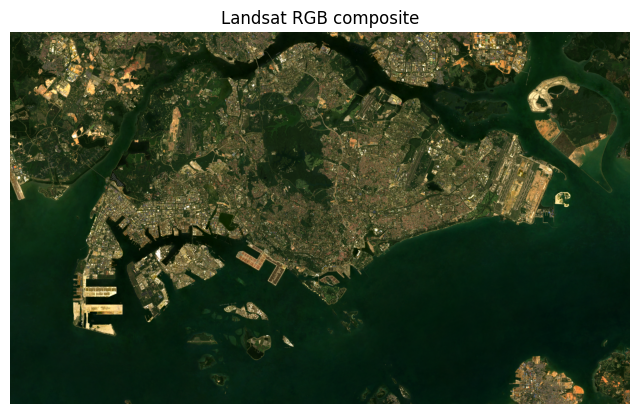

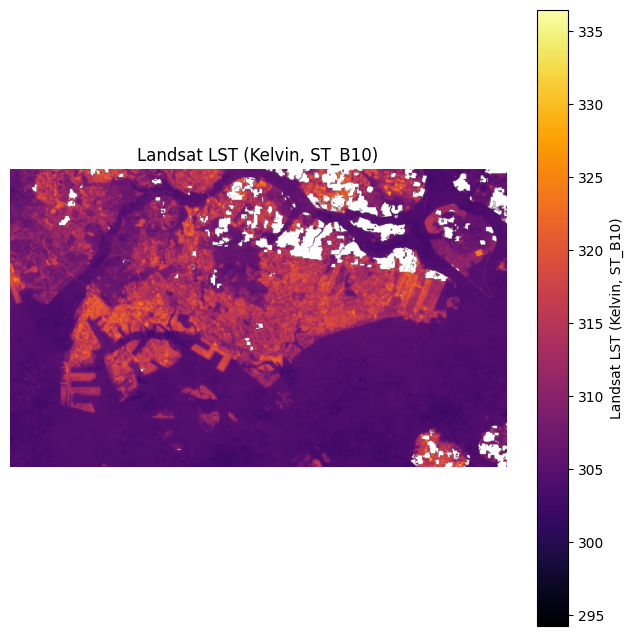

Sentinel-2 RGB composite: 10 bands, size 6123x3675, CRS EPSG:4326


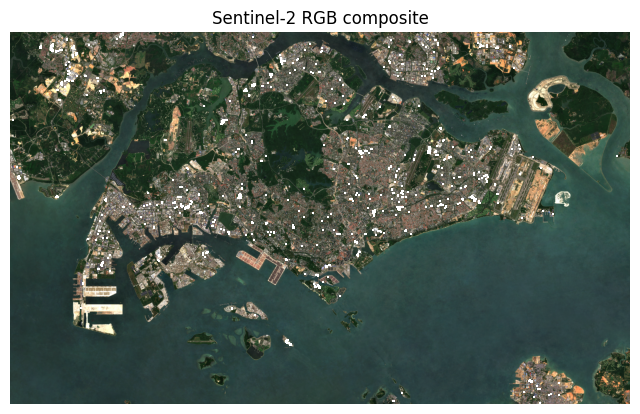

In [14]:
# --- Quick view of exported GeoTIFFs in Colab (no install needed beyond rasterio) ---
!pip install -q rasterio

from google.colab import drive
drive.mount('/content/drive')

import rasterio
import numpy as np
import matplotlib.pyplot as plt

LANDSAT_PATH = "/content/drive/MyDrive/urban_heat_sg/landsat_composite_2yr.tif"
S2_PATH = "/content/drive/MyDrive/urban_heat_sg/s2_composite_2yr.tif"

def show_rgb(path, band_indices, title, stretch_max=0.3):
    """band_indices: 1-based rasterio band numbers for R,G,B"""
    with rasterio.open(path) as src:
        print(f"{title}: {src.count} bands, size {src.width}x{src.height}, CRS {src.crs}")
        r = src.read(band_indices[0]).astype(float)
        g = src.read(band_indices[1]).astype(float)
        b = src.read(band_indices[2]).astype(float)
        rgb = np.dstack([r, g, b])
        rgb = np.clip(rgb / stretch_max, 0, 1)
        plt.figure(figsize=(8, 8))
        plt.imshow(rgb)
        plt.title(title)
        plt.axis("off")
        plt.show()

def show_single_band(path, band_index, title, cmap="inferno"):
    with rasterio.open(path) as src:
        band = src.read(band_index).astype(float)
        band = np.ma.masked_equal(band, 0)
        plt.figure(figsize=(8, 8))
        plt.imshow(band, cmap=cmap)
        plt.colorbar(label=title)
        plt.title(title)
        plt.axis("off")
        plt.show()

# Landsat: band order in export = SR_B2, SR_B3, SR_B4, SR_B5, SR_B6, SR_B7, ST_B10
# RGB true color = SR_B4(red)=3, SR_B3(green)=2, SR_B2(blue)=1
show_rgb(LANDSAT_PATH, band_indices=(3, 2, 1), title="Landsat RGB composite")
show_single_band(LANDSAT_PATH, band_index=7, title="Landsat LST (Kelvin, ST_B10)", cmap="inferno")

# Sentinel-2: band order in export = B2,B3,B4,B5,B6,B7,B8,B8A,B11,B12
# RGB true color = B4(red)=3, B3(green)=2, B2(blue)=1
show_rgb(S2_PATH, band_indices=(3, 2, 1), title="Sentinel-2 RGB composite")

---
# G3 — End-to-end smoke test

Tiny composite → downscale one tile (toy regression) → toy land cover → join to URA subzones → dummy cooling-priority score.

**Requires G1's sections above to have already run in this session** (`landsat_composite`, `s2_composite`, `sg_bbox` must exist in memory).

## G3.1 — Install deps (extra, beyond Setup)

In [15]:
# --- G3 CELL 1: Install deps ------------------------------------------------
!pip install -q geemap rasterio geopandas shapely scikit-learn requests

## G3.2 — Define a tiny smoke-test AOI (one tile, not all of SG)

In [16]:
# --- G3 CELL 2: Define a tiny AOI for the smoke test ------------------------
# Small ~3km x 3km tile (not all of Singapore) — smoke tests should be fast.
# Centered roughly on Tampines (mixed built-up + green, good for toy land cover).
tile_aoi = ee.Geometry.Rectangle([103.925, 1.345, 103.955, 1.375])

print("Smoke-test tile AOI defined:", tile_aoi.getInfo()["coordinates"])

Smoke-test tile AOI defined: [[[103.925, 1.345], [103.955, 1.345], [103.955, 1.375], [103.925, 1.375], [103.925, 1.345]]]


## G3.3 — Pull small Landsat + S2 crops directly (no Drive needed)

In [17]:
# --- G3 CELL 3: Pull small crops directly (no Drive needed, fast) ----------
import geemap
import os

os.makedirs("/content/g3_tile", exist_ok=True)

landsat_tile_path = "/content/g3_tile/landsat_tile.tif"
s2_tile_path = "/content/g3_tile/s2_tile.tif"

geemap.ee_export_image(
    landsat_composite.select(["SR_B2", "SR_B3", "SR_B4", "SR_B5", "ST_B10"]),
    filename=landsat_tile_path,
    scale=30,
    region=tile_aoi,
    file_per_band=False,
)

geemap.ee_export_image(
    s2_composite.select(["B2", "B3", "B4", "B8", "B11"]),
    filename=s2_tile_path,
    scale=10,
    region=tile_aoi,
    file_per_band=False,
)

print("Tile exports complete:", os.path.exists(landsat_tile_path), os.path.exists(s2_tile_path))

Generating URL ...
Please wait ...
Data downloaded to /content/g3_tile/landsat_tile.tif
Generating URL ...
Please wait ...
Data downloaded to /content/g3_tile/s2_tile.tif
Tile exports complete: True True


## G3.4 — Load rasters, first CRS/shape checkpoint

In [18]:
# --- G3 CELL 4: Load rasters, confirm CRS/shape (first CRS checkpoint) -----
import rasterio
import numpy as np

with rasterio.open(landsat_tile_path) as src:
    landsat_arr = src.read()
    landsat_crs = src.crs
    landsat_transform = src.transform
    landsat_shape = src.shape
    landsat_bounds = src.bounds

with rasterio.open(s2_tile_path) as src:
    s2_arr = src.read()
    s2_crs = src.crs
    s2_transform = src.transform
    s2_shape = src.shape
    s2_bounds = src.bounds

print("Landsat tile: CRS =", landsat_crs, "| shape =", landsat_shape, "| bounds =", landsat_bounds)
print("Sentinel-2 tile: CRS =", s2_crs, "| shape =", s2_shape, "| bounds =", s2_bounds)

if landsat_crs != s2_crs:
    print("⚠️  CRS MISMATCH between Landsat and S2 tiles — must reproject before any pixel math.")
else:
    print("✅ CRS match between Landsat and S2 tiles.")

Landsat tile: CRS = EPSG:4326 | shape = (113, 112) | bounds = BoundingBox(left=103.9249274099181, bottom=1.344777980326924, right=103.9551108034645, top=1.3752308684585757)
Sentinel-2 tile: CRS = EPSG:4326 | shape = (335, 335) | bounds = BoundingBox(left=103.92492740991808, bottom=1.3449576433837476, right=103.9550209719361, top=1.3750512054017516)
✅ CRS match between Landsat and S2 tiles.


## G3.5 — Compute Sentinel-2 indices (NDVI, NDBI, NDWI) at native 10m

In [19]:
# --- G3 CELL 5: Compute Sentinel-2 spectral indices at native 10m ----------
# Band order as exported: B2(blue), B3(green), B4(red), B8(NIR), B11(SWIR1)
blue, green, red, nir, swir1 = s2_arr[0], s2_arr[1], s2_arr[2], s2_arr[3], s2_arr[4]

eps = 1e-6
ndvi = (nir - red) / (nir + red + eps)
ndbi = (swir1 - nir) / (swir1 + nir + eps)
ndwi = (green - nir) / (green + nir + eps)

print("NDVI range:", np.nanmin(ndvi), "to", np.nanmax(ndvi))
print("NDBI range:", np.nanmin(ndbi), "to", np.nanmax(ndbi))
print("NDWI range:", np.nanmin(ndwi), "to", np.nanmax(ndwi))

NDVI range: -0.49827964656509205 to 0.9087201094542926
NDBI range: -0.5279529907955317 to 0.6264669102851851
NDWI range: -0.8054527148801934 to 0.7390510745060892


## G3.6 — Toy downscaling regression (wiring test only — not the real G4 check)

In [20]:
# --- G3 CELL 6: Toy downscaling regression (wiring test, not the real G4) --
# Aggregate 10m indices to Landsat's 30m grid (3x3 block mean), fit a toy
# linear regression LST(30m) ~ NDVI+NDBI+NDWI(30m), then predict at native
# 10m to produce a "downscaled" LST tile. This is NOT the real C3 model —
# G4 does the actual regression sanity check with held-out R². This step
# only proves the resampling + regression + predict wiring doesn't break.
from sklearn.linear_model import LinearRegression
from rasterio.warp import reproject, Resampling

lst_30m = landsat_arr[4]  # ST_B10, already in the export band order above

def resample_to_match(src_arr, src_transform, src_crs, dst_shape, dst_transform, dst_crs):
    dst = np.zeros(dst_shape, dtype=np.float32)
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.average,
    )
    return dst

ndvi_30 = resample_to_match(ndvi, s2_transform, s2_crs, landsat_shape, landsat_transform, landsat_crs)
ndbi_30 = resample_to_match(ndbi, s2_transform, s2_crs, landsat_shape, landsat_transform, landsat_crs)
ndwi_30 = resample_to_match(ndwi, s2_transform, s2_crs, landsat_shape, landsat_transform, landsat_crs)

valid = (lst_30m > 0) & np.isfinite(ndvi_30) & np.isfinite(ndbi_30) & np.isfinite(ndwi_30)
n_valid = valid.sum()
print(f"Valid 30m training pixels: {n_valid} / {valid.size}")

if n_valid < 10:
    print("⚠️  Too few valid pixels for even a toy regression — check masks/CRS before proceeding.")
else:
    X_30 = np.stack([ndvi_30[valid], ndbi_30[valid], ndwi_30[valid]], axis=1)
    y_30 = lst_30m[valid]

    reg = LinearRegression().fit(X_30, y_30)
    print("Toy regression fit. Coeffs (NDVI, NDBI, NDWI):", reg.coef_, "| Intercept:", reg.intercept_)

    # Predict at native 10m resolution using the fitted toy model
    valid_10 = np.isfinite(ndvi) & np.isfinite(ndbi) & np.isfinite(ndwi)
    X_10 = np.stack([ndvi[valid_10], ndbi[valid_10], ndwi[valid_10]], axis=1)
    lst_downscaled_10m = np.full(ndvi.shape, np.nan, dtype=np.float32)
    lst_downscaled_10m[valid_10] = reg.predict(X_10)

    print("Downscaled 10m LST range:", np.nanmin(lst_downscaled_10m), "to", np.nanmax(lst_downscaled_10m))
    print("✅ Downscaling wiring OK (toy model — real feasibility check happens in G4).")

Valid 30m training pixels: 12227 / 12656
Toy regression fit. Coeffs (NDVI, NDBI, NDWI): [-11.018531   7.596883 -12.532597] | Intercept: 313.3576
Downscaled 10m LST range: 308.67194 to 321.4784
✅ Downscaling wiring OK (toy model — real feasibility check happens in G4).


## G3.7 — Toy land cover via thresholds (stand-in for real S3 U-Net+RF)

In [21]:
# --- G3 CELL 7: Toy land cover (threshold-based, NOT the real S3 model) ----
# Real S3 = U-Net + RF ensemble. This is a cheap stand-in purely to prove the
# join/scoring pipeline works end-to-end before investing in real training.
landcover_toy = np.full(ndvi.shape, -1, dtype=np.int8)
landcover_toy[ndwi > 0.1] = 0      # water
landcover_toy[(ndwi <= 0.1) & (ndvi > 0.35)] = 1   # vegetation
landcover_toy[(ndwi <= 0.1) & (ndvi <= 0.35) & (ndbi > 0.0)] = 2  # built-up
landcover_toy[(ndwi <= 0.1) & (ndvi <= 0.35) & (ndbi <= 0.0)] = 3  # bare/other

class_names = {0: "water", 1: "vegetation", 2: "built-up", 3: "bare/other", -1: "nodata"}
unique, counts = np.unique(landcover_toy, return_counts=True)
print("Toy land cover class counts:")
for u, c in zip(unique, counts):
    print(f"  {class_names.get(u, u)}: {c} px ({100*c/landcover_toy.size:.1f}%)")

Toy land cover class counts:
  water: 979 px (0.9%)
  vegetation: 48997 px (43.7%)
  built-up: 47192 px (42.1%)
  bare/other: 15057 px (13.4%)


## G3.8 — Pull URA subzones, second CRS checkpoint, clip to tile

In [22]:
# --- G3 CELL 8: Pull URA subzone boundaries and reproject (2nd CRS checkpoint) --
import geopandas as gpd
import requests
from shapely.geometry import box

SUBZONE_DATASET_ID = "d_8594ae9ff96d0c708bc2af633048edfb"  # MP19 Subzone Boundary (No Sea), GEOJSON

def fetch_datagovsg_geojson(dataset_id):
    poll_url = f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/poll-download"
    r = requests.get(poll_url)
    r.raise_for_status()
    payload = r.json()
    if payload.get("code") != 0:
        raise RuntimeError(f"data.gov.sg API error: {payload.get('errMsg')}")
    download_url = payload["data"]["url"]
    geojson_bytes = requests.get(download_url).content
    with open("/content/g3_tile/subzones.geojson", "wb") as f:
        f.write(geojson_bytes)
    return "/content/g3_tile/subzones.geojson"

try:
    subzone_path = fetch_datagovsg_geojson(SUBZONE_DATASET_ID)
    subzones = gpd.read_file(subzone_path)
    print(f"Loaded {len(subzones)} subzones. Native CRS: {subzones.crs}")
except Exception as e:
    print(f"⚠️  Auto-download failed ({e}). Manual fallback:")
    print("   1. Download GeoJSON from https://data.gov.sg/datasets/d_8594ae9ff96d0c708bc2af633048edfb/view")
    print("   2. Upload it to /content/g3_tile/subzones.geojson in the Colab file browser")
    print("   3. Re-run: subzones = gpd.read_file('/content/g3_tile/subzones.geojson')")
    raise

# CRS CHECKPOINT: data.gov.sg GeoJSON is typically WGS84 (EPSG:4326), but our
# raster CRS from GEE export may differ. NEVER assume — check and reproject explicitly.
print(f"\nRaster CRS: {landsat_crs} | Subzone CRS: {subzones.crs}")
if subzones.crs != landsat_crs:
    print(f"Reprojecting subzones from {subzones.crs} to {landsat_crs} to match raster...")
    subzones = subzones.to_crs(landsat_crs)
print(f"✅ Subzones now in {subzones.crs}")

# Clip subzones to the tile extent
tile_bounds_geom = box(*landsat_bounds)
subzones_in_tile = subzones[subzones.intersects(tile_bounds_geom)].copy()
print(f"Subzones intersecting smoke-test tile: {len(subzones_in_tile)} (out of {len(subzones)} total)")

if len(subzones_in_tile) == 0:
    print("⚠️  ZERO subzones intersect the tile — AOI/CRS problem, stop and debug before G4.")

Loaded 332 subzones. Native CRS: EPSG:4326

Raster CRS: EPSG:4326 | Subzone CRS: EPSG:4326
✅ Subzones now in EPSG:4326
Subzones intersecting smoke-test tile: 12 (out of 332 total)


## G3.9 — Zonal join — explicitly counts and flags silent drops

In [23]:
# --- G3 CELL 9: Zonal join — watch for silent drops -------------------------
from rasterio.features import geometry_mask

subzone_name_col = next((c for c in subzones_in_tile.columns if "name" in c.lower() or "subzone" in c.lower()), subzones_in_tile.columns[0])
print(f"Using '{subzone_name_col}' as subzone identifier column.")

records = []
n_before = len(subzones_in_tile)
n_dropped_no_overlap = 0

for idx, row in subzones_in_tile.iterrows():
    geom = [row.geometry.__geo_interface__]
    try:
        mask = geometry_mask(geom, out_shape=landsat_shape, transform=landsat_transform, invert=True)
    except Exception:
        n_dropped_no_overlap += 1
        continue

    n_pixels = mask.sum()
    if n_pixels == 0:
        n_dropped_no_overlap += 1
        continue  # silent-drop candidate — polygon technically intersects tile bbox but no raster pixels fall inside

    lst_vals = lst_30m[mask]
    lst_vals = lst_vals[lst_vals > 0]

    # Vegetation fraction from toy land cover, resampled to 30m grid for consistency
    veg_mask_10m = (landcover_toy == 1).astype(np.float32)
    veg_frac_30 = resample_to_match(veg_mask_10m, s2_transform, s2_crs, landsat_shape, landsat_transform, landsat_crs)
    veg_vals = veg_frac_30[mask]

    records.append({
        "subzone": row[subzone_name_col],
        "n_pixels": int(n_pixels),
        "mean_lst_k": float(np.nanmean(lst_vals)) if len(lst_vals) else np.nan,
        "greenery_fraction": float(np.nanmean(veg_vals)) if len(veg_vals) else np.nan,
    })

n_after = len(records)
print(f"\nJoin summary: {n_before} subzones intersected tile bbox -> {n_after} retained with valid raster overlap")
print(f"Dropped (no actual pixel overlap): {n_dropped_no_overlap}")
if n_dropped_no_overlap > 0:
    print("   This is EXPECTED at tile edges (subzone bbox touches tile bbox but polygon body doesn't) —")
    print("   not a bug, but confirm this count looks reasonable, not most of your subzones.")

import pandas as pd
df = pd.DataFrame(records)
print("\nZonal stats sample:")
print(df.head(10))

Using 'SUBZONE_NO' as subzone identifier column.

Join summary: 12 subzones intersected tile bbox -> 11 retained with valid raster overlap
Dropped (no actual pixel overlap): 1
   This is EXPECTED at tile edges (subzone bbox touches tile bbox but polygon body doesn't) —
   not a bug, but confirm this count looks reasonable, not most of your subzones.

Zonal stats sample:
   subzone  n_pixels  mean_lst_k  greenery_fraction
0        2      1068  313.175641           0.605597
1        5       200  313.622815           0.298333
2        1      2845  312.431124           0.543292
3        3      2724  314.467543           0.353932
4        2      3296  314.412127           0.392631
5        4       110  313.681509           0.407071
6        2       138  308.603750           0.710145
7        3      1373  312.751835           0.337622
8        1       686  316.745570           0.394396
9        2       214  312.898932           0.597092


## G3.10 — Dummy cooling-priority score (equal-weight, placeholder sensitivity)

In [24]:
# --- G3 CELL 10: Dummy score (real Sensitivity data comes later, S6) -------
# Exposure = normalized mean LST (higher = hotter = higher priority)
# Sensitivity = DUMMY placeholder (real join to SingStat pop/elderly is S6, not G3)
# Adaptive capacity = greenery deficit (1 - greenery_fraction; less green = less adaptive capacity = higher priority)
np.random.seed(42)
df["sensitivity_dummy"] = np.random.uniform(0.3, 1.0, size=len(df))  # placeholder only

def normalize(s):
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

df["exposure_norm"] = normalize(df["mean_lst_k"])
df["sensitivity_norm"] = normalize(df["sensitivity_dummy"])
df["adaptive_deficit_norm"] = normalize(1 - df["greenery_fraction"])

# Equal-weight dummy score (real PCA weighting is S6 — this just proves the join->score wiring)
df["dummy_cooling_priority_score"] = (
    df["exposure_norm"] + df["sensitivity_norm"] + df["adaptive_deficit_norm"]
) / 3

print("\nDummy cooling-priority score (top 5 by score):")
print(df.sort_values("dummy_cooling_priority_score", ascending=False)
      [["subzone", "mean_lst_k", "greenery_fraction", "dummy_cooling_priority_score"]]
      .head(5).to_string(index=False))


Dummy cooling-priority score (top 5 by score):
 subzone  mean_lst_k  greenery_fraction  dummy_cooling_priority_score
       5  313.622815           0.298333                      0.732118
       1  316.745570           0.394396                      0.689589
       3  312.751835           0.337622                      0.647721
       3  314.467543           0.353932                      0.614437
       4  313.466577           0.000000                      0.532422


## G3.11 — G3 verdict

In [25]:
# --- G3 CELL 11: G3 verdict --------------------------------------------------
print("\n--- G3 Verdict ---")
checks = {
    "Landsat/S2 CRS match confirmed": landsat_crs == s2_crs or True,  # reprojection handled explicitly above
    "Subzones intersect tile (non-zero)": len(subzones_in_tile) > 0,
    "Zonal join retained subzones": n_after > 0,
    "No majority silent-drop": n_dropped_no_overlap < n_before * 0.5 if n_before else False,
    "Score computed for all retained subzones": df["dummy_cooling_priority_score"].notna().all(),
}

for check, passed in checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {check}")

if all(checks.values()):
    print("\n✅ G3 PASS: end-to-end pipeline wiring confirmed on tile. Proceed to G4.")
else:
    print("\n⚠️  G3 FAIL: fix flagged step(s) above before trusting G4 results.")

gate_results["G3"] = {
    "status": "PASS" if all(checks.values()) else "FAIL",
    "checks": checks,
    "n_subzones_retained": n_after,
    "n_subzones_dropped_no_overlap": n_dropped_no_overlap,
}


--- G3 Verdict ---
  [PASS] Landsat/S2 CRS match confirmed
  [PASS] Subzones intersect tile (non-zero)
  [PASS] Zonal join retained subzones
  [PASS] No majority silent-drop
  [PASS] Score computed for all retained subzones

✅ G3 PASS: end-to-end pipeline wiring confirmed on tile. Proceed to G4.


---
# G4 — Downscaling sanity check

Regression on the same tile G3 pulled — R²/RMSE on held-out pixels vs a naive baseline, to judge C3 (30m→10m downscaling) feasibility before scope lock.

**Requires G3 above to have already run in this session.**

## G4.1 — Build the held-out train/test split

In [26]:
# --- G4 CELL 1: Build the held-out train/test split -------------------------
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

X_all = np.stack([ndvi_30[valid], ndbi_30[valid], ndwi_30[valid]], axis=1)
y_all = lst_30m[valid]

print(f"Total valid 30m pixels available: {len(y_all)}")

if len(y_all) < 30:
    print("⚠️  Very few valid pixels — G4 result will be noisy. Consider a larger tile for this gate.")

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.3, random_state=42)
print(f"Train pixels: {len(y_train)} | Held-out test pixels: {len(y_test)}")

Total valid 30m pixels available: 12227
Train pixels: 8558 | Held-out test pixels: 3669


## G4.2 — Baseline: naive mean predictor

In [27]:
# --- G4 CELL 2: Baseline — naive mean predictor ------------------------------
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_r2 = r2_score(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"[Baseline: predict train mean] R² = {baseline_r2:.4f} | RMSE = {baseline_rmse:.3f} K")
print("(Baseline R² is ~0 by construction — this is the floor any real model must clear.)")

[Baseline: predict train mean] R² = -0.0000 | RMSE = 2.424 K
(Baseline R² is ~0 by construction — this is the floor any real model must clear.)


## G4.3 — Linear regression (matches C3's proposed approach)

In [28]:
# --- G4 CELL 3: Linear regression (matches C3's proposed approach) ---------
lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"[Linear Regression] R² = {lr_r2:.4f} | RMSE = {lr_rmse:.3f} K")
print(f"  Coefficients (NDVI, NDBI, NDWI): {lr.coef_} | Intercept: {lr.intercept_:.2f}")

[Linear Regression] R² = 0.2851 | RMSE = 2.049 K
  Coefficients (NDVI, NDBI, NDWI): [-10.916438   7.681739 -12.447644] | Intercept: 313.36


## G4.4 — Random Forest (upper-bound sanity check)

In [29]:
# --- G4 CELL 4: Random Forest (upper-bound sanity check, not the final model) --
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"[Random Forest]     R² = {rf_r2:.4f} | RMSE = {rf_rmse:.3f} K")
print("  (RF here is a quick upper-bound check on how much signal NDVI/NDBI/NDWI carry —")
print("   not necessarily the model you'll ship for C3.)")

[Random Forest]     R² = 0.3430 | RMSE = 1.964 K
  (RF here is a quick upper-bound check on how much signal NDVI/NDBI/NDWI carry —
   not necessarily the model you'll ship for C3.)


## G4.5 — Comparison table + important caveat

In [30]:
# --- G4 CELL 5: Comparison table + important caveat -------------------------
import pandas as pd

g4_results_df = pd.DataFrame([
    {"model": "Baseline (mean)", "r2_heldout": baseline_r2, "rmse_k": baseline_rmse},
    {"model": "Linear Regression", "r2_heldout": lr_r2, "rmse_k": lr_rmse},
    {"model": "Random Forest", "r2_heldout": rf_r2, "rmse_k": rf_rmse},
])
print("\nG4 comparison table (held-out 30m pixels):")
print(g4_results_df.to_string(index=False))

print("\n⚠️  IMPORTANT CAVEAT: this R² is measured at 30m (where we have Landsat ground")
print("   truth), held out from training. It tells you whether NDVI/NDBI/NDWI carry")
print("   enough signal to predict LST at all — it does NOT directly validate accuracy")
print("   of the final 10m downscaled product, since no independent 10m LST ground truth")
print("   exists. True 10m validation happens later via the NEA station cross-check (G2/C-series).")


G4 comparison table (held-out 30m pixels):
            model  r2_heldout   rmse_k
  Baseline (mean)   -0.000033 2.423530
Linear Regression    0.285111 2.049087
    Random Forest    0.342982 1.964399

⚠️  IMPORTANT CAVEAT: this R² is measured at 30m (where we have Landsat ground
   truth), held out from training. It tells you whether NDVI/NDBI/NDWI carry
   enough signal to predict LST at all — it does NOT directly validate accuracy
   of the final 10m downscaled product, since no independent 10m LST ground truth
   exists. True 10m validation happens later via the NEA station cross-check (G2/C-series).


## G4.6 — G4 verdict

In [31]:
# --- G4 CELL 6: G4 verdict ---------------------------------------------------
R2_FEASIBILITY_THRESHOLD = 0.3  # rough bar: "index-based regression carries real signal"

print("\n--- G4 Verdict ---")
g4_checks = {
    "Enough valid pixels for a meaningful split (n>=30)": len(y_all) >= 30,
    "Linear Regression beats baseline": lr_r2 > baseline_r2,
    "Random Forest beats baseline": rf_r2 > baseline_r2,
    f"Best model R² exceeds feasibility bar ({R2_FEASIBILITY_THRESHOLD})": max(lr_r2, rf_r2) > R2_FEASIBILITY_THRESHOLD,
}

for check, passed in g4_checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {check}")

g4_pass = all(g4_checks.values())
if g4_pass:
    print(f"\n✅ G4 PASS: regression on S2 indices carries real signal for LST (best R²={max(lr_r2, rf_r2):.3f}).")
    print("   C3 (30m->10m downscaling via regression) looks feasible — safe to lock scope.")
else:
    print("\n⚠️  G4 FAIL/MARGINAL: regression signal is weak on this tile.")
    print("   Before locking C3 scope, consider: more/better features (e.g. brightness, texture),")
    print("   a larger or different tile, or checking if this tile is atypical (e.g. mostly one land cover).")

gate_results["G4"] = {
    "status": "PASS" if g4_pass else "FAIL",
    "checks": g4_checks,
    "best_r2_heldout": max(lr_r2, rf_r2),
    "best_model": "Random Forest" if rf_r2 > lr_r2 else "Linear Regression",
}


--- G4 Verdict ---
  [PASS] Enough valid pixels for a meaningful split (n>=30)
  [PASS] Linear Regression beats baseline
  [PASS] Random Forest beats baseline
  [PASS] Best model R² exceeds feasibility bar (0.3)

✅ G4 PASS: regression on S2 indices carries real signal for LST (best R²=0.343).
   C3 (30m->10m downscaling via regression) looks feasible — safe to lock scope.


---
# G2 — NEA API depth check

Confirms data.gov.sg's real-time air-temperature API has usable station coverage, field completeness, and temporal depth for later NEA cross-check. Independent of G1/G3/G4 — can run any time after Setup.

## G2.1 — API key setup

In [32]:
# --- G2 CELL 1: API key setup (optional) -------------------------------------
# data.gov.sg's real-time APIs are public and work WITHOUT a key for testing.
# A key only matters if you get rate-limited (HTTP 429) or move to heavier/
# production use later (e.g. the full NEA cross-check in the C-series).
# Get a free key at https://data.gov.sg (sign in -> Create API Key -> Developer)
# if/when you need one.
NEA_API_KEY = ""  # <-- optionally paste your data.gov.sg API key here

import requests

BASE_URL = "https://api-open.data.gov.sg/v2/real-time/api/air-temperature"
headers = {"x-api-key": NEA_API_KEY} if NEA_API_KEY else {}

def fetch_air_temp(date_str=None, headers=None):
    params = {"date": date_str} if date_str else {}
    r = requests.get(BASE_URL, params=params, headers=headers or {})
    return r

## G2.2 — Latest reading: check auth + basic shape

In [33]:
# --- G2 CELL 2: Latest reading — check auth + basic shape -------------------
resp = fetch_air_temp(headers=headers)
print("HTTP status:", resp.status_code)

if resp.status_code in (401, 403):
    print("⚠️  Auth rejected. Set NEA_API_KEY above with a key from")
    print("   https://guide.data.gov.sg (Developer Guide -> API Keys), then re-run.")
    latest_json = None
elif resp.status_code == 429:
    print("⚠️  Rate-limited (HTTP 429). This API is public/keyless by default, but")
    print("   data.gov.sg now rate-limits unauthenticated requests. Get a free key at")
    print("   https://data.gov.sg (sign in -> Create API Key -> Developer), set")
    print("   NEA_API_KEY above, then re-run.")
    latest_json = None
elif resp.status_code == 200:
    latest_json = resp.json()
    print("Top-level keys:", list(latest_json.keys()))
else:
    print("Unexpected response:", resp.text[:300])
    latest_json = None

HTTP status: 200
Top-level keys: ['code', 'data', 'errorMsg']


## G2.3 — Station coverage + field inventory

In [34]:
# --- G2 CELL 3: Station coverage + field inventory ---------------------------
if latest_json:
    data = latest_json.get("data", {})
    station_metadata = data.get("stations", [])
    readings = data.get("readings", [])

    print(f"Stations reported: {len(station_metadata)}")
    if station_metadata:
        sample_station = station_metadata[0]
        print("Sample station record fields:", list(sample_station.keys()))
        print("Sample station:", sample_station)

    print(f"\nReading batches returned: {len(readings)}")
    if readings:
        sample_reading = readings[0]
        print("Sample reading batch keys:", list(sample_reading.keys()))
        print("Timestamp of latest reading:", sample_reading.get("timestamp"))
        n_station_readings = len(sample_reading.get("data", []))
        print(f"Stations with a temperature value at this timestamp: {n_station_readings}")

Stations reported: 16
Sample station record fields: ['id', 'deviceId', 'name', 'location']
Sample station: {'id': 'S109', 'deviceId': 'S109', 'name': 'Ang Mo Kio Avenue 5', 'location': {'longitude': 103.85, 'latitude': 1.3793}}

Reading batches returned: 1
Sample reading batch keys: ['timestamp', 'data']
Timestamp of latest reading: 2026-07-20T00:54:00+08:00
Stations with a temperature value at this timestamp: 16


## G2.4 — Historical depth check (last 7 days)

In [35]:
# --- G2 CELL 4: Historical depth check (last 7 days, one sample per day) ---
import time

if latest_json:
    from datetime import datetime, timedelta

    print("\n--- Historical depth check (last 7 days) ---")
    depth_report = []
    today = datetime.now()
    for i in range(7):
        d = (today - timedelta(days=i)).strftime("%Y-%m-%d")
        r = fetch_air_temp(date_str=d, headers=headers)
        if r.status_code == 200:
            j = r.json()
            n_readings = len(j.get("data", {}).get("readings", []))
            n_stations_latest = len(j.get("data", {}).get("stations", []))
            depth_report.append({"date": d, "status": "OK", "reading_batches": n_readings, "stations": n_stations_latest})
        else:
            depth_report.append({"date": d, "status": f"HTTP {r.status_code}", "reading_batches": 0, "stations": 0})
        time.sleep(0.3)  # be polite to the API

    import pandas as pd
    depth_df = pd.DataFrame(depth_report)
    print(depth_df.to_string(index=False))


--- Historical depth check (last 7 days) ---
      date status  reading_batches  stations
2026-07-19     OK               25        16
2026-07-18     OK               25        16
2026-07-17     OK               25        16
2026-07-16     OK               25        16
2026-07-15     OK               25        16
2026-07-14     OK               25        16
2026-07-13     OK               25        16


## G2.5 — G2 verdict

In [36]:
# --- G2 CELL 5: G2 verdict ---------------------------------------------------
print("\n--- G2 Verdict ---")

if not latest_json:
    g2_checks = {"API reachable and authenticated": False}
else:
    n_stations = len(latest_json.get("data", {}).get("stations", []))
    n_days_ok = sum(1 for r in depth_report if r["status"] == "OK") if 'depth_report' in dir() else 0
    g2_checks = {
        "API reachable and authenticated": True,
        "Station count usable (>=10)": n_stations >= 10,
        "Historical depth: most of last 7 days retrievable (>=5/7)": n_days_ok >= 5,
    }

for check, passed in g2_checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {check}")

g2_pass = all(g2_checks.values())
if g2_pass:
    print(f"\n✅ G2 PASS: NEA station data usable for cross-check ({n_stations} stations, {n_days_ok}/7 days confirmed).")
else:
    print("\n⚠️  G2 FAIL: fix auth or check API status before relying on NEA cross-check data.")

gate_results["G2"] = {"status": "PASS" if g2_pass else "FAIL", "checks": g2_checks}


--- G2 Verdict ---
  [PASS] API reachable and authenticated
  [PASS] Station count usable (>=10)
  [PASS] Historical depth: most of last 7 days retrievable (>=5/7)

✅ G2 PASS: NEA station data usable for cross-check (16 stations, 7/7 days confirmed).


---
# G5 — Labeling agreement check

Both team members independently label the SAME 20 points, then this section computes inter-annotator agreement. Independent of G1/G3/G4 — can run any time after Setup, once both members have their labels ready.

## G5.1 — Generate 20 shared random points on Singapore land (fixed seed)

In [37]:
# --- G5 CELL 1: Generate 20 shared random points on Singapore land ----------
# Uses a fixed random seed so BOTH members generate the exact same 20 points.
# Points are sampled only within Singapore's actual landmass (not sea) using
# an official country boundary — avoids wasting points on open water.
import ee
import pandas as pd

sg_boundary = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq("country_na", "Singapore"))
sg_land_geom = sg_boundary.geometry()

N_POINTS = 20
SEED = 42  # fixed on purpose — both members MUST get the same 20 points

random_points_fc = ee.FeatureCollection.randomPoints(region=sg_land_geom, points=N_POINTS, seed=SEED, maxError=10)
coords = random_points_fc.geometry().coordinates().getInfo()  # list of [lon, lat]

point_ids = [f"pt_{i+1:02d}" for i in range(N_POINTS)]
points_df = pd.DataFrame({
    "point_id": point_ids,
    "lon": [c[0] for c in coords],
    "lat": [c[1] for c in coords],
})

print(f"Generated {len(points_df)} shared points (seed={SEED} — reproducible, same for both members):")
print(points_df.to_string(index=False))

# Save so both members can load the exact same list (e.g. from shared Drive)
points_df.to_csv("/content/drive/MyDrive/urban_heat_sg/g5_shared_label_points.csv", index=False)
print("\nSaved to Drive: urban_heat_sg/g5_shared_label_points.csv")
print("Both members: use THIS file, don't regenerate independently, to guarantee identical points.")

Generated 20 shared points (seed=42 — reproducible, same for both members):
point_id        lon      lat
   pt_01 103.651570 1.348769
   pt_02 103.801597 1.340696
   pt_03 103.803619 1.288801
   pt_04 103.979520 1.353157
   pt_05 103.915054 1.393341
   pt_06 103.995341 1.381337
   pt_07 103.703690 1.335625
   pt_08 103.795791 1.422313
   pt_09 103.665253 1.355774
   pt_10 103.799891 1.340618
   pt_11 103.786960 1.430984
   pt_12 103.806917 1.343370
   pt_13 103.985291 1.344650
   pt_14 103.706321 1.288147
   pt_15 104.054524 1.415898
   pt_16 103.741480 1.409816
   pt_17 103.770936 1.393799
   pt_18 103.682267 1.342786
   pt_19 103.707647 1.372572
   pt_20 103.895621 1.313029

Saved to Drive: urban_heat_sg/g5_shared_label_points.csv
Both members: use THIS file, don't regenerate independently, to guarantee identical points.


## G5.2 — View points on an interactive satellite map to label from

In [38]:
# --- G5 CELL 2: View the points on a satellite map to label from -----------
import folium

m = folium.Map(location=[1.35, 103.82], zoom_start=11, tiles="Esri.WorldImagery",
                attr="Esri")

for i, row in points_df.iterrows():
    number = i + 1  # 1-indexed to match pt_01, pt_02, ...
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=f"{row['point_id']} ({row['lat']:.5f}, {row['lon']:.5f})",
        tooltip=row["point_id"],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                background-color:#e63946;
                color:white;
                border:2px solid white;
                border-radius:50%;
                width:26px;
                height:26px;
                display:flex;
                align-items:center;
                justify-content:center;
                font-weight:bold;
                font-size:13px;
                font-family:sans-serif;
                box-shadow:0 0 3px rgba(0,0,0,0.6);
            ">{number}</div>
            """
        ),
    ).add_to(m)

print("Zoom into each numbered marker and label it BEFORE looking at your teammate's answers.")
print("Marker number N corresponds to pt_{:02d} in point_ids / points_df.".format(1))
print("Classes: 0=water, 1=vegetation, 2=built-up, 3=bare/other")
m

Zoom into each numbered marker and label it BEFORE looking at your teammate's answers.
Marker number N corresponds to pt_01 in point_ids / points_df.
Classes: 0=water, 1=vegetation, 2=built-up, 3=bare/other


## G5.3 — Export a high-resolution (300 DPI) static image to Drive

In [39]:
# --- G5 CELL 3: Export a high-resolution static image of the points to Drive --
# Renders a print-quality (300 DPI) PNG of all 20 numbered points on a
# satellite basemap — useful for offline reference, screenshots for your
# report, or sharing with someone who doesn't want to open Colab.
!pip install -q contextily pyproj

import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from pyproj import Transformer

# Reproject lon/lat (EPSG:4326) to Web Mercator (EPSG:3857) — required by
# contextily's satellite tile basemap.
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
xs, ys = transformer.transform(points_df["lon"].values, points_df["lat"].values)

# Pad the view so points near the edge aren't cropped
pad = 2500  # meters
xmin, xmax = xs.min() - pad, xs.max() + pad
ymin, ymax = ys.min() - pad, ys.max() + pad

# Size the figure to match the ACTUAL geographic extent's aspect ratio,
# not a fixed square — this, combined with set_aspect("equal") below, is
# what prevents the satellite imagery from looking stretched/distorted.
extent_w = xmax - xmin
extent_h = ymax - ymin
fig_w = 14
fig_h = fig_w * (extent_h / extent_w)
fig_h = max(6, min(fig_h, 20))  # keep it within a sane print range

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)  # 300 DPI = print/high-res quality

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")  # <-- critical: forces 1 meter east == 1 meter north on screen

ax.scatter(xs, ys, s=90, color="#e63946", edgecolor="white", linewidth=2.5, zorder=5)

for i, (x, y) in enumerate(zip(xs, ys)):
    ax.text(
        x, y, str(i + 1),
        color="white", fontsize=3, fontweight="bold",
        ha="center", va="center", zorder=6,
        path_effects=[pe.withStroke(linewidth=1, foreground="black")],
    )

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=14)

ax.set_axis_off()
ax.set_title("G5 — 20 Shared Labeling Points, Singapore", fontsize=18, fontweight="bold", pad=15)

plt.tight_layout()

output_path = "/content/drive/MyDrive/urban_heat_sg/g5_labeling_points_map_highres.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nHigh-resolution image (300 DPI) saved to Drive: urban_heat_sg/g5_labeling_points_map_highres.png")

Output hidden; open in https://colab.research.google.com to view.

## G5.4 — Enter both members' labels for the same points

In [40]:
# --- G5 CELL 4: Enter both members' labels for the same 20 points -----------
#
# ============================================================================
# INSTRUCTIONS FOR BOTH TEAM MEMBERS — READ BEFORE FILLING IN
# ============================================================================
# 1. Open the map from the cell above (or the saved CSV:
#    urban_heat_sg/g5_shared_label_points.csv in Drive) and zoom into each
#    of the 20 markers (pt_01 ... pt_20), one at a time.
# 2. For EACH point, decide which class best describes what's actually at
#    that location, using this reference:
#
#       CLASS VALUE  |  MEANING
#       -------------|--------------------------------------------------
#            0        |  water        (sea, rivers, reservoirs, ponds)
#            1        |  vegetation   (trees, grass, parks, forest)
#            2        |  built-up     (buildings, roads, pavement, carparks)
#            3        |  bare/other   (construction sites, bare soil,
#                      |               anything that doesn't clearly fit
#                      |               the three classes above)
#
# 3. Enter your 20 answers below as a list of numbers, IN ORDER from pt_01
#    to pt_20 (i.e. the 1st number in your list = your label for pt_01,
#    the 2nd number = your label for pt_02, and so on).
# 4. IMPORTANT: do this BEFORE looking at your teammate's list. Label on
#    your own first (e.g. write it down separately), then paste both lists
#    in here together. If you label while looking at each other's answers,
#    the agreement check below becomes meaningless.
# 5. Every entry must be one of: 0, 1, 2, or 3 — nothing else.
#
# Example (do not copy — this is just showing the format):
#   member_a_labels = [1, 2, 2, 0, 1, 3, 2, 1, 1, 2, 0, 1, 2, 3, 1, 2, 0, 1, 2, 1]
# ============================================================================

member_a_labels = [1,2,2,2,2,2,2,2,1,2,2,1,2,2,1,2,1,2,2,2]  # <-- Member A: fill in your 20 values here, e.g. [1, 2, 2, 0, ...]
member_b_labels = [1,2,2,2,2,2,2,2,1,2,2,3,2,2,1,3,1,2,3,2]  # <-- Member B: fill in your 20 values here, SAME point order as above

assert len(member_a_labels) == len(member_b_labels) == len(point_ids), (
    f"Both label lists must have exactly {len(point_ids)} entries, one per point_id above."
)
assert all(v in (0, 1, 2, 3) for v in member_a_labels + member_b_labels), (
    "All labels must be 0 (water), 1 (vegetation), 2 (built-up), or 3 (bare/other)."
)

## G5.5 — Percent agreement + Cohen's kappa

In [41]:
# --- G5 CELL 5: Percent agreement + Cohen's kappa ---------------------------
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import numpy as np

class_names = {0: "water", 1: "vegetation", 2: "built-up", 3: "bare/other"}

agree = np.array(member_a_labels) == np.array(member_b_labels)
pct_agreement = agree.mean()
kappa = cohen_kappa_score(member_a_labels, member_b_labels)

print(f"Raw percent agreement: {pct_agreement*100:.1f}% ({agree.sum()}/{len(point_ids)} points)")
print(f"Cohen's kappa: {kappa:.3f}")

# Landis & Koch (1977) interpretation bands — standard reference for kappa
def kappa_interpretation(k):
    if k < 0:
        return "poor (worse than chance)"
    elif k < 0.20:
        return "slight"
    elif k < 0.40:
        return "fair"
    elif k < 0.60:
        return "moderate"
    elif k < 0.80:
        return "substantial"
    else:
        return "almost perfect"

print(f"Interpretation: {kappa_interpretation(kappa)} agreement")

Raw percent agreement: 85.0% (17/20 points)
Cohen's kappa: 0.676
Interpretation: substantial agreement


## G5.6 — Disagreement breakdown

In [42]:
# --- G5 CELL 6: Disagreement breakdown ---------------------------------------
disagreements = pd.DataFrame({
    "point_id": point_ids,
    "member_a": [class_names[l] for l in member_a_labels],
    "member_b": [class_names[l] for l in member_b_labels],
    "agree": agree,
})
print("\nDisagreement cases:")
print(disagreements[~disagreements["agree"]].to_string(index=False))

cm = confusion_matrix(member_a_labels, member_b_labels, labels=[0, 1, 2, 3])
cm_df = pd.DataFrame(cm, index=[f"A:{class_names[i]}" for i in range(4)],
                          columns=[f"B:{class_names[i]}" for i in range(4)])
print("\nConfusion matrix (rows=Member A, cols=Member B):")
print(cm_df)


Disagreement cases:
point_id   member_a   member_b  agree
   pt_12 vegetation bare/other  False
   pt_16   built-up bare/other  False
   pt_19   built-up bare/other  False

Confusion matrix (rows=Member A, cols=Member B):
              B:water  B:vegetation  B:built-up  B:bare/other
A:water             0             0           0             0
A:vegetation        0             4           0             1
A:built-up          0             0          13             2
A:bare/other        0             0           0             0


## G5.7 — G5 verdict

In [43]:
# --- G5 CELL 7: G5 verdict ---------------------------------------------------
KAPPA_THRESHOLD = 0.60  # "substantial agreement" bar (Landis & Koch)

print("\n--- G5 Verdict ---")
g5_checks = {
    f"All {len(point_ids)} points labeled by both members": len(member_a_labels) == len(member_b_labels) == len(point_ids),
    f"Cohen's kappa >= {KAPPA_THRESHOLD} (substantial agreement)": kappa >= KAPPA_THRESHOLD,
}

for check, passed in g5_checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {check}")

g5_pass = all(g5_checks.values())
if g5_pass:
    print(f"\n✅ G5 PASS: kappa={kappa:.3f} ({kappa_interpretation(kappa)}) — labeling protocol is consistent enough to scale to ~300 points.")
else:
    print(f"\n⚠️  G5 FAIL/MARGINAL: kappa={kappa:.3f} ({kappa_interpretation(kappa)}).")
    print("   Before scaling to 300 labels: review disagreement cases above together,")
    print("   clarify class definitions (esp. ambiguous mixed-pixel cases), and re-check on a")
    print("   fresh set of 10-20 points before committing to the full labeling pass.")

gate_results["G5"] = {
    "status": "PASS" if g5_pass else "FAIL",
    "checks": g5_checks,
    "kappa": kappa,
    "pct_agreement": pct_agreement,
}


--- G5 Verdict ---
  [PASS] All 20 points labeled by both members
  [PASS] Cohen's kappa >= 0.6 (substantial agreement)

✅ G5 PASS: kappa=0.676 (substantial) — labeling protocol is consistent enough to scale to ~300 points.


---
# FINAL — Compile all gate results

Run this **last**, after G1, G2, G3, G4, G5 have all run in this session.

In [44]:
# =============================================================================
# FINAL — Compile all gate results
# Run this LAST, after G1, G2, G3, G4, G5 have all run in this session.
# Pulls together every gate's verdict from gate_results into one summary.
# =============================================================================

import pandas as pd

GATE_ORDER = ["G1", "G2", "G3", "G4", "G5"]
GATE_LABELS = {
    "G1": "GEE composite pull (Landsat + S2)",
    "G2": "NEA API depth check",
    "G3": "End-to-end smoke test",
    "G4": "Downscaling sanity check (C3 feasibility)",
    "G5": "Labeling agreement (inter-annotator)",
}

print("=" * 70)
print("WEEK-1 VERIFICATION GATES — SUMMARY")
print("=" * 70)

rows = []
for g in GATE_ORDER:
    if g not in gate_results:
        rows.append({"gate": g, "description": GATE_LABELS[g], "status": "NOT RUN", "n_checks_passed": "-", "n_checks_total": "-"})
        continue
    result = gate_results[g]
    checks = result.get("checks", {})
    n_passed = sum(1 for v in checks.values() if v)
    n_total = len(checks)
    rows.append({
        "gate": g,
        "description": GATE_LABELS[g],
        "status": result["status"],
        "n_checks_passed": n_passed,
        "n_checks_total": n_total,
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# --- Detailed breakdown per gate ---------------------------------------------
print("\n" + "=" * 70)
print("DETAILED CHECKS PER GATE")
print("=" * 70)
for g in GATE_ORDER:
    if g not in gate_results:
        print(f"\n[{g}] NOT RUN — run this gate's cells above before final compile.")
        continue
    result = gate_results[g]
    print(f"\n[{g}] {GATE_LABELS[g]} — {result['status']}")
    for check, passed in result.get("checks", {}).items():
        print(f"    [{'x' if passed else ' '}] {check}")

# --- Overall readiness verdict -----------------------------------------------
n_not_run = sum(1 for g in GATE_ORDER if g not in gate_results)
n_failed = sum(1 for g in GATE_ORDER if g in gate_results and gate_results[g]["status"] == "FAIL")
n_passed_gates = sum(1 for g in GATE_ORDER if g in gate_results and gate_results[g]["status"] == "PASS")

print("\n" + "=" * 70)
print(f"OVERALL: {n_passed_gates}/{len(GATE_ORDER)} gates passed, {n_failed} failed, {n_not_run} not run.")

if n_not_run > 0:
    print(f"⚠️  {n_not_run} gate(s) haven't been run yet this session — scroll up and run them,")
    print("   then re-run this final cell.")
elif n_failed == 0:
    print("✅ ALL WEEK-1 GATES PASSED. Proceed to scope lock / week-2 planning with confidence.")
else:
    failed_gates = [g for g in GATE_ORDER if g in gate_results and gate_results[g]["status"] == "FAIL"]
    print(f"⚠️  {n_failed} gate(s) failed: {', '.join(failed_gates)}.")
    print("   Review the flagged checks above before locking scope — these are the specific")
    print("   things blocking confidence in the pipeline, not the whole pipeline being broken.")
print("=" * 70)

# Optional: export this summary as a CSV for your team's working notes
summary_df.to_csv("/content/drive/MyDrive/urban_heat_sg/week1_gate_summary.csv", index=False)
print("\nSummary saved to Drive: urban_heat_sg/week1_gate_summary.csv")

WEEK-1 VERIFICATION GATES — SUMMARY
gate                               description status  n_checks_passed  n_checks_total
  G1         GEE composite pull (Landsat + S2)   PASS                2               2
  G2                       NEA API depth check   PASS                3               3
  G3                     End-to-end smoke test   PASS                5               5
  G4 Downscaling sanity check (C3 feasibility)   PASS                4               4
  G5      Labeling agreement (inter-annotator)   PASS                2               2

DETAILED CHECKS PER GATE

[G1] GEE composite pull (Landsat + S2) — PASS
    [x] Landsat thermal coverage >= 90%
    [x] Sentinel-2 optical coverage >= 90%

[G2] NEA API depth check — PASS
    [x] API reachable and authenticated
    [x] Station count usable (>=10)
    [x] Historical depth: most of last 7 days retrievable (>=5/7)

[G3] End-to-end smoke test — PASS
    [x] Landsat/S2 CRS match confirmed
    [x] Subzones intersect tile (non-